# Bengali Character Classifier — Focused Training

This notebook trains a specialised **EfficientNet-B0** classifier specifically for Bengali character recognition.

Given the limited number of real Bengali character samples in the competition dataset, the model is trained with an aggressive data-augmentation strategy and a class-weighted Focal Loss to maximise accuracy on the small real-world Bengali distribution.

> **Note:** This notebook is run **separately** from the main pipeline. Its outputs (improved Bengali prediction rows) are merged into the primary submission using `merge_bengali_predictions.py`. See the README for the full pipeline order.

In [6]:
# --- COMPETITION DATASET PATHS ---
# These paths expect the competition dataset to be added via '+ Add Data' on Kaggle.
# Search for: 'handwritten-multiscript-character-segmentation-recognition'
# If running locally, replace with your local extraction path.

import os
import json
import cv2
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

# Define dataset paths
IMAGE_DIR = Path("/kaggle/input/competitions/handwritten-multiscript-character-segmentation-recognition/JU_CMATER/train/images")
ANNOTATION_DIR = Path("/kaggle/input/competitions/handwritten-multiscript-character-segmentation-recognition/JU_CMATER/train/annotations")
OUTPUT_DIR = Path("/kaggle/working/extracted_characters")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def is_bengali_or_punctuation(label):
    """
    Filters labels to keep only Bengali characters, punctuation, and digits.
    Ignores standard English alphabets (A-Z, a-z).
    """
    if not label:
        return False
        
    label = label.strip()
    
    # 1. Parse Unicode hex string (e.g., "U+006C" or "U+0985") to actual character
    if label.startswith("U+"):
        try:
            hex_val = label.split("+")[1]
            char = chr(int(hex_val, 16))
        except Exception as e:
            # If parsing fails, fall back to the raw string
            char = label
    else:
        char = label

    # Take the first character for evaluation
    first_char = char[0]
    code_point = ord(first_char)
    
    # 2. STRICTLY IGNORE English Alphabets (A-Z, a-z)
    if (65 <= code_point <= 90) or (97 <= code_point <= 122):
        return False
        
    # 3. KEEP Bengali Block (U+0980 to U+09FF) & Bengali Danda (U+0964)
    if (0x0980 <= code_point <= 0x09FF) or code_point == 0x0964:
        return True
        
    # 4. KEEP standard punctuation / special characters (ASCII punctuation)
    if (33 <= code_point <= 47) or (58 <= code_point <= 64) or (91 <= code_point <= 96) or (123 <= code_point <= 126):
        return True
        
    # If it's something else (like numbers or other scripts), skip it
    return False

# Track class distribution
class_counts = defaultdict(int)

# Loop through all annotation JSON files
json_files = list(ANNOTATION_DIR.glob("*.json"))
print(f"Found {len(json_files)} annotation files. Starting extraction...")

for json_path in tqdm(json_files):
    # Load JSON data
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # Find corresponding image (checking common extensions)
    image_extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.PNG']
    image_path = None
    for ext in image_extensions:
        potential_path = IMAGE_DIR / f"{json_path.stem}{ext}"
        if potential_path.exists():
            image_path = potential_path
            break
            
    if image_path is None:
        # print(f"Warning: Image not found for {json_path.name}")
        continue
        
    # Load the image
    image = cv2.imread(str(image_path))
    if image is None:
        continue
        
    img_h, img_w, _ = image.shape

    # Process each bounding box shape
    for shape in data.get('shapes', []):
        label = shape.get('label', '').strip()
        
        # Apply our filtering rule
        if not is_bengali_or_punctuation(label):
            # print(str(image_path))
            continue
            
        points = shape.get('points', [])
        if len(points) < 2:
            continue
            
        # Extract coordinates (handles float formats from Labelme/Kaggle JSONs)
        x1, y1 = points[0]
        x2, y2 = points[1]
        
        # Ensure correct bounding box ordering (min/max)
        xmin, xmax = int(min(x1, x2)), int(max(x1, x2))
        ymin, ymax = int(min(y1, y2)), int(max(y1, y2))
        
        # Clip coordinates to image boundaries to prevent empty crops
        xmin, ymin = max(0, xmin), max(0, ymin)
        xmax, ymax = min(img_w, xmax), min(img_h, ymax)
        
        # Skip invalid/empty crops
        if xmax <= xmin or ymax <= ymin:
            continue
            
        # Crop the character
        cropped_char = image[ymin:ymax, xmin:xmax]
        
        # Create a safe directory name for the class (replacing '/' or 'U+' for file paths if needed)
        safe_label = label.replace("/", "_")
        char_dir = OUTPUT_DIR / safe_label
        char_dir.mkdir(parents=True, exist_ok=True)
        
        # Save cropped character image
        class_counts[label] += 1
        crop_filename = f"{json_path.stem}_{class_counts[label]}.png"
        cv2.imwrite(str(char_dir / crop_filename), cropped_char)

# --- Generate Comprehensive Report ---
print("\n" + "="*50)
print("COMPREHENSIVE CLASS SIZE REPORT")
print("="*50)
print(f"{'Class/Unicode':<20} | {'Count':<10}")
print("-"*50)

total_extracted = 0
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

for cls, count in sorted_classes:
    # Try to print the actual character next to unicode for easier readability
    try:
        if cls.startswith("U+"):
            readable = chr(int(cls.split("+")[1], 16))
            display_name = f"{cls} ({readable})"
        else:
            display_name = cls
    except:
        display_name = cls
        
    print(f"{display_name:<20} | {count:<10}")
    total_extracted += count

print("-"*50)
print(f"Total valid classes extracted: {len(sorted_classes)}")
print(f"Total character images saved:  {total_extracted}")
print("="*50)

Found 17 annotation files. Starting extraction...


100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 17/17 [00:01<00:00,  9.01it/s]


COMPREHENSIVE CLASS SIZE REPORT
Class/Unicode        | Count     
--------------------------------------------------
U+09BE (à¦¾)           | 101       
U+09B0 (à¦°)           | 52        
U+09C7 (à§‡)           | 51        
U+002E (.)           | 39        
U+003D (=)           | 38        
U+0029 ())           | 37        
U+09A8 (à¦¨)           | 33        
U+09BF (à¦¿)           | 30        
U+09AC (à¦¬)           | 30        
U+003A (:)           | 27        
U+002D (-)           | 27        
U+0028 (()           | 27        
U+002C (,)           | 27        
U+09AE (à¦®)           | 24        
U+0995 (à¦•)           | 23        
U+09B2 (à¦²)           | 18        
U+002B (+)           | 16        
U+09AA (à¦ª)           | 16        
U+09DF (à§Ÿ)           | 16        
U+007C (|)           | 15        
U+09B8 (à¦¸)           | 14        
U+09B6 (à¦¶)           | 14        
U+09CD+U+09AF (à§)    | 14        
U+09B9 (à¦¹)           | 14        
U+09A4 (à¦¤)           | 13        


# Dataset and augmentation definitions
Define a custom dataset and a random slicing augmentation strategy to inflate minority class samples during training.

In [7]:
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
from collections import Counter
from PIL import Image
from pathlib import Path

# --- Custom Transform: 60-70% Slicing ---
class RandomSlice:
    """Randomly slices 60% to 70% of the image's width and height."""
    def __call__(self, img):
        w, h = img.size
        # Pick a random ratio between 60% and 70%
        ratio_w = random.uniform(0.6, 0.7)
        ratio_h = random.uniform(0.6, 0.7)
        
        slice_w = int(w * ratio_w)
        slice_h = int(h * ratio_h)
        
        # Random starting point for the slice
        x = random.randint(0, w - slice_w)
        y = random.randint(0, h - slice_h)
        
        return img.crop((x, y, x + slice_w, y + slice_h))

# --- Custom Dataset with Conditional Augmentation ---
class ImbalancedCharDataset(Dataset):
    def __init__(self, root_dir, minority_threshold=10, target_size=(64, 64)):
        self.root_dir = Path(root_dir)
        self.target_size = target_size
        
        # Load dataset structure using torchvision's ImageFolder logic
        self.base_dataset = datasets.ImageFolder(root=self.root_dir)
        self.classes = self.base_dataset.classes
        self.class_to_idx = self.base_dataset.class_to_idx
        
        # Calculate class frequencies to identify minority classes
        self.targets = self.base_dataset.targets
        class_counts = Counter(self.targets)
        self.minority_classes = {cls_idx for cls_idx, count in class_counts.items() if count < minority_threshold}
        
        # Define standard base transforms (applied to everything)
        self.base_transform = transforms.Compose([
            transforms.Resize(target_size),
            transforms.Grayscale(num_output_channels=1), # Characters are usually better in 1-channel
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
        
        # Define minority transforms (Aggressive slicing + standard)
        self.minority_transform = transforms.Compose([
            RandomSlice(),
            transforms.Resize(target_size),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img_path, label = self.base_dataset.samples[idx]
        img = Image.open(img_path).convert('RGB')
        
        # Apply specific transforms based on class frequency
        if label in self.minority_classes:
            img = self.minority_transform(img)
        else:
            img = self.base_transform(img)
            
        return img, label

    def get_class_weights(self):
        """Calculates inverse frequency weights for the loss function."""
        class_counts = Counter(self.targets)
        total_samples = len(self.targets)
        num_classes = len(self.classes)
        
        weights = []
        for i in range(num_classes):
            # Inverse frequency: Total / (Num_Classes * Count)
            # Add +1 smoothing to avoid division by zero or overly massive weights for 1-sample classes
            count = class_counts.get(i, 1)
            weight = total_samples / (num_classes * count)
            weights.append(weight)
            
        return torch.FloatTensor(weights)

# --- Initialization ---
# Assuming OUTPUT_DIR from previous script is where the folders are
# dataset = ImbalancedCharDataset(root_dir="/kaggle/working/extracted_characters")
# dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
# print(f"Classes: {len(dataset.classes)}, Minorities: {len(dataset.minority_classes)}")

# EfficientNet dataset wrapper and model
Create a 3-channel dataset wrapper for EfficientNet and define a Bengali character classifier using EfficientNet-B0.

In [9]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from PIL import Image
from pathlib import Path

# --- Quick Adjustment to Dataset for 3-Channel EfficientNet ---
class EfficientNetCharDataset(ImbalancedCharDataset):
    """
    Inherits from our previous dataset but forces 3-channel output 
    so pre-trained ImageNet weights function perfectly.
    """
    def __init__(self, root_dir, minority_threshold=10, target_size=(224, 224)):
        # EfficientNet performs significantly better with 224x224 resolutions
        super().__init__(root_dir, minority_threshold, target_size)
        
        # Override transforms to keep 3 channels (RGB replication)
        self.base_transform = transforms.Compose([
            transforms.Resize(target_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        self.minority_transform = transforms.Compose([
            RandomSlice(),
            transforms.Resize(target_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

# --- EfficientNet Model Architecture ---
class BengaliEfficientNet(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super(BengaliEfficientNet, self).__init__()
        
        # Load pre-trained EfficientNet-B0
        if pretrained:
            weights = models.EfficientNet_B0_Weights.DEFAULT
        else:
            weights = None
            
        self.model = models.efficientnet_b0(weights=weights)
        
        # Replace the final linear layer in the classifier
        # EfficientNet-B0 features out of the backbone is 1280
        in_features = self.model.classifier[1].in_features
        
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.1, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)

# Weighted focal loss
Define a FocalLoss class to emphasize harder examples and combine this with class weights for imbalanced training.

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        """
        weight (Tensor): 1D tensor of class weights.
        gamma (float): Focusing parameter to down-weight easy examples (default: 2.0).
        """
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Calculate standard cross entropy with weights
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        
        # Calculate the probability of the true class (pt)
        pt = torch.exp(-ce_loss)
        
        # Apply focal loss formula: (1 - pt)^gamma * CE_loss
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Training loop setup
Initialize training settings, optimizer, scheduler, and run the EfficientNet training loop with progress reporting.

In [27]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR  # <--- 1. Import the Scheduler
from tqdm import tqdm
import torch

# 1. Configuration & Device Selection
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 80
BATCH_SIZE = 16 
DATA_DIR = "/kaggle/working/extracted_characters"
SAVE_PATH = "/kaggle/working/bengali_efficientnet_best.pth"

print(f"Using device: {DEVICE}")

# (Assuming dataset, sampler, and dataloader are already initialized)
print(f"Dataset Loaded with Oversampler. Total Draws per Epoch: {len(dataset)}")

# 2. Instantiate Model and Weighted Focal Loss
model = BengaliEfficientNet(num_classes=num_classes, pretrained=True).to(DEVICE)
class_weights = dataset.get_class_weights().to(DEVICE)
criterion = FocalLoss(weight=class_weights, gamma=2.0)

# 3. Optimizer (Weight decay set to 0.0 for easier memorization)
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=0.0)

# <--- 2. Initialize Scheduler right after the optimizer
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# 4. Engine Loop
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    pbar = tqdm(dataloader, desc=f"Epoch [{epoch:02d}/{EPOCHS}]", leave=True)
    
    # --- BATCH LOOP ---
    for images, labels in pbar:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_predictions += torch.sum(preds == labels.data)
        total_samples += images.size(0)
        
        current_loss = running_loss / total_samples
        current_acc = (correct_predictions.double() / total_samples) * 100
        
        # Get current learning rate to display on the progress bar
        current_lr = optimizer.param_groups[0]['lr']
        pbar.set_postfix({
            'Loss': f"{current_loss:.4f}", 
            'Acc': f"{current_acc:.2f}%",
            'LR': f"{current_lr:.6f}"
        })
    # --- END OF BATCH LOOP ---
    
    # <--- 3. Step the scheduler AFTER the batch loop finishes, but INSIDE the epoch loop
    scheduler.step()
    
    epoch_acc = (correct_predictions.double() / total_samples) * 100
    
    # Check if absolute memorization is hit
    if epoch_acc >= 99.9:
        print(f"\n[Target Achieved] Absolute dataset memorization hit at Epoch {epoch}!")
        break

# 5. Save the model after training finishes
torch.save(model.state_dict(), SAVE_PATH)
print(f"Model saved successfully to {SAVE_PATH}")

Using device: cuda
Dataset Loaded with Oversampler. Total Draws per Epoch: 921


Epoch [80/80]: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 58/58 [00:06<00:00,  9.58it/s, Loss=0.0348, Acc=94.03%, LR=0.000001]


Model saved successfully to /kaggle/working/bengali_efficientnet_best.pth


# Augmentation preview
Visualize a raw character image and several random slices produced by the augmentation routine.

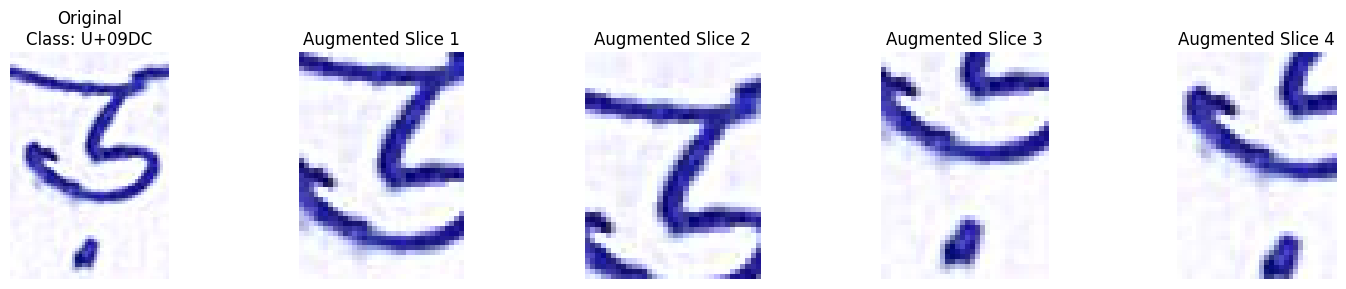

In [23]:
import matplotlib.pyplot as plt
import random
from PIL import Image

# 1. Grab a random image from the raw dataset
# Using base_dataset.samples which contains (filepath, label) tuples
sample_idx = -22
img_path, label_idx = dataset.base_dataset.samples[sample_idx]
class_name = dataset.classes[label_idx]

# Open the raw image
original_img = Image.open(img_path).convert('RGB')

# 2. Initialize our custom slicer
slicer = RandomSlice()

# 3. Create a plot
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

# Plot Original
axes[0].imshow(original_img)
axes[0].set_title(f"Original\nClass: {class_name}")
axes[0].axis('off')

# Plot 4 random augmented slices
for i in range(1, 5):
    sliced_img = slicer(original_img)
    axes[i].imshow(sliced_img)
    axes[i].set_title(f"Augmented Slice {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# YOLO

# YOLO dataset conversion
Install YOLO dependencies and convert annotation JSONs into YOLO single-class format for detection training.

In [28]:
# --- COMPETITION DATASET PATHS ---
# These paths expect the competition dataset to be added via '+ Add Data' on Kaggle.
# Search for: 'handwritten-multiscript-character-segmentation-recognition'
# If running locally, replace with your local extraction path.

!pip install ultralytics -q
import os
import json
import shutil
import cv2
from pathlib import Path
from tqdm import tqdm

# Original Paths
IMAGE_DIR = Path("/kaggle/input/competitions/handwritten-multiscript-character-segmentation-recognition/JU_CMATER/train/images")
ANNOTATION_DIR = Path("/kaggle/input/competitions/handwritten-multiscript-character-segmentation-recognition/JU_CMATER/train/annotations")

# New YOLO Paths
YOLO_DIR = Path("/kaggle/working/yolo_dataset")
YOLO_IMAGES = YOLO_DIR / "images" / "train"
YOLO_LABELS = YOLO_DIR / "labels" / "train"
YOLO_IMAGES.mkdir(parents=True, exist_ok=True)
YOLO_LABELS.mkdir(parents=True, exist_ok=True)

# Reuse your filtering logic
def is_bengali_or_punctuation(label):
    if not label: return False
    label = label.strip()
    if label.startswith("U+"):
        try:
            hex_val = label.split("+")[1]
            char = chr(int(hex_val, 16))
        except Exception:
            char = label
    else:
        char = label
    
    first_char = char[0]
    code_point = ord(first_char)
    if (65 <= code_point <= 90) or (97 <= code_point <= 122): return False
    if (0x0980 <= code_point <= 0x09FF) or code_point == 0x0964: return True
    if (33 <= code_point <= 47) or (58 <= code_point <= 64) or (91 <= code_point <= 96) or (123 <= code_point <= 126): return True
    return False

json_files = list(ANNOTATION_DIR.glob("*.json"))
print("Converting JSONs to YOLO single-class format...")

valid_images = 0
for json_path in tqdm(json_files):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    # Find image
    image_path = None
    for ext in ['.jpg', '.jpeg', '.png']:
        if (IMAGE_DIR / f"{json_path.stem}{ext}").exists():
            image_path = IMAGE_DIR / f"{json_path.stem}{ext}"
            break
            
    if not image_path: continue
    
    # Read image dimensions
    img = cv2.imread(str(image_path))
    if img is None: continue
    img_h, img_w, _ = img.shape
    
    yolo_annotations = []
    
    for shape in data.get('shapes', []):
        label = shape.get('label', '')
        if not is_bengali_or_punctuation(label):
            continue
            
        points = shape.get('points', [])
        if len(points) < 2: continue
            
        x1, y1 = points[0]
        x2, y2 = points[1]
        
        xmin, xmax = min(x1, x2), max(x1, x2)
        ymin, ymax = min(y1, y2), max(y1, y2)
        
        # YOLO normalized format calculations
        x_center = ((xmin + xmax) / 2) / img_w
        y_center = ((ymin + ymax) / 2) / img_h
        width = (xmax - xmin) / img_w
        height = (ymax - ymin) / img_h
        
        # Class 0 for EVERYTHING (Single Class Detection)
        yolo_annotations.append(f"0 {x_center} {y_center} {width} {height}")
        
    # Only copy image and save label if there are valid Bengali characters
    if len(yolo_annotations) > 0:
        # Save TXT
        label_path = YOLO_LABELS / f"{json_path.stem}.txt"
        with open(label_path, 'w') as f:
            f.write("\n".join(yolo_annotations))
            
        # Copy Image
        dest_image_path = YOLO_IMAGES / image_path.name
        if not dest_image_path.exists():
            shutil.copy(image_path, dest_image_path)
        valid_images += 1

print(f"Dataset conversion complete. {valid_images} images prepared for YOLO.")

     â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 41.2/41.2 kB 2.3 MB/s eta 0:00:00
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 1.3/1.3 MB 27.3 MB/s eta 0:00:0000:01
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 12.2/12.2 MB 70.5 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cum

100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 17/17 [00:01<00:00, 10.07it/s]

Dataset conversion complete. 15 images prepared for YOLO.


# YOLO training configuration
Create a YOLO YAML dataset configuration that points to the converted training images and labels.

In [29]:
import yaml

yaml_data = {
    'train': '/kaggle/working/yolo_dataset/images/train',
    # Deliberately set val == train: this is a focused training run on a very small
# Bengali-only dataset where we want to maximise in-distribution accuracy
# rather than standard generalisation. This is intentional for this notebook only.
'val': '/kaggle/working/yolo_dataset/images/train',
    'nc': 1,
    'names': ['character']
}

yaml_path = '/kaggle/working/bengali_yolo.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_data, f, default_flow_style=False)
    
print(f"Created YAML config at {yaml_path}")

Created YAML config at /kaggle/working/bengali_yolo.yaml


# YOLO training run
Train YOLOv8 to train the model to high accuracy on the prepared dataset for high-recall character detection.

In [30]:
from ultralytics import YOLO

# 1. Load a pre-trained YOLOv8 small model
model = YOLO('yolov8s.pt')

# 2. Train the model to aggressively overfit
# - epochs=100: Plenty of time to memorize the bounding boxes
# - imgsz=1024: Document images need high resolution so small characters aren't lost
# - hsv_h/s/v & fliplr: Turned down/off because handwritten text shouldn't be color-shifted or flipped horizontally
# - box=7.5: High weight on bounding box regression (localization) vs classification
print("Starting YOLO training. This will automatically save the best model to /kaggle/working/runs/detect/train/weights/best.pt")

results = model.train(
    data='/kaggle/working/bengali_yolo.yaml',
    epochs=100,
    imgsz=1024,
    batch=8,
    optimizer='AdamW',
    lr0=0.001,
    box=7.5,           # Force the model to care heavily about perfect IoU > 0.50
    cls=0.5,           # We don't care about classification (it's just 1 class)
    fliplr=0.0,        # NEVER flip text horizontally
    mosaic=0.5,        # Mosaic helps with finding dense, clustered objects
    project='/kaggle/working',
    name='bengali_yolo_run',
    save=True
)

Creating new Ultralytics Settings v0.0.6 file âœ… 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Starting YOLO training. This will automatically save the best model to /kaggle/working/runs/detect/train/weights/best.pt
Ultralytics 8.4.60 ðŸš€ Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/bengali_yolo.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist

# Two-stage inference and submission
Load YOLO and EfficientNet models, detect character boxes, classify each crop, and write the submission file.

In [ ]:
# --- COMPETITION DATASET PATHS ---
# These paths expect the competition dataset to be added via '+ Add Data' on Kaggle.
# Search for: 'handwritten-multiscript-character-segmentation-recognition'
# If running locally, replace with your local extraction path.

import os
import json
import cv2
import torch
import pandas as pd
from pathlib import Path
from PIL import Image
from torchvision import transforms
from ultralytics import YOLO

# --- 1. Setup Paths & Files ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TEST_DIR = Path("/kaggle/input/competitions/handwritten-multiscript-character-segmentation-recognition/JU_CMATER/test/images")

# The specific files you requested
# --- TEST FILES ---
test_files = ["101.jpeg", "102.jpeg"]

# --- 2. Load Both Models ---
print("Loading YOLOv8 and EfficientNet models...")
# --- MODEL PATH ---
# 'bengali_yolo_run' is the YOLO run name set in the training cell above.
# After training, the best weights are saved to /kaggle/working/bengali_yolo_run/weights/best.pt
# If the run name is different (check the YOLO training output), update the path below.
yolo_model = YOLO('/kaggle/working/bengali_yolo_run/weights/best.pt')

# Assuming BengaliEfficientNet and num_classes are still in your notebook's memory
# --- MODEL + IN-MEMORY DEPENDENCY ---
# BengaliEfficientNet, num_classes, and dataset.classes MUST be in memory from the training cells above.
# If running inference in a fresh kernel session, re-run the training cells first
# (or load num_classes and class names from a saved JSON file).
# 'bengali_efficientnet_best.pth' is saved to /kaggle/working/ during training.
classifier_model = BengaliEfficientNet(num_classes=num_classes, pretrained=False).to(DEVICE)
classifier_model.load_state_dict(torch.load("/kaggle/working/bengali_efficientnet_best.pth"))
classifier_model.eval()

# Assuming `dataset.classes` is still in memory from training to map index back to Unicode strings
classes = dataset.classes 

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

submission_data = []

# --- 3. Run 2-Stage Inference ---
for filename in test_files:
    image_path = TEST_DIR / filename
    page_id = image_path.stem  # Extracts "101" and "102"
    
    print(f"Processing {filename}...")
    img = cv2.imread(str(image_path))
    if img is None:
        print(f"Warning: Could not read {image_path}. Skipping.")
        continue
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # STAGE 1: YOLO Detection (High Recall Settings)
    results = yolo_model(img, conf=0.05, iou=0.6, verbose=False)
    
    page_predictions = []
    
    for box in results[0].boxes.xyxy:
        # Get coordinates
        x1, y1, x2, y2 = map(float, box[:4]) # Keep as float to match standard competition outputs
        
        # Prevent invalid 0-pixel crops
        if x2 <= x1 or y2 <= y1:
            continue
            
        # STAGE 2: EfficientNet Classification
        crop = img_rgb[int(y1):int(y2), int(x1):int(x2)]
        crop_pil = Image.fromarray(crop)
        
        input_tensor = inference_transform(crop_pil).unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            output = classifier_model(input_tensor)
            _, predicted_idx = torch.max(output, 1)
            
        predicted_label = classes[predicted_idx.item()]
        
        # Build the exact dictionary structure required
        page_predictions.append({
            "script":1,
            "unicode_value": predicted_label,
            "bbox": [round(x1, 4), round(y1, 4), round(x2, 4), round(y2, 4)]
        })
        
    # Serialize the list of dictionaries to a JSON formatted string
    predictions_json = json.dumps(page_predictions)
    
    submission_data.append({
        "page_id": page_id,
        "predictions": predictions_json
    })
    
    print(f" -> Found {len(page_predictions)} characters in {filename}")

# --- 4. Generate submission.csv ---
submission_df = pd.DataFrame(submission_data)
submission_csv_path = "/kaggle/working/submission_bengali_only.csv"
submission_df.to_csv(submission_csv_path, index=False)

print(f"\nInference complete! File saved to: {submission_csv_path}")
display(submission_df.head())

Loading YOLOv8 and EfficientNet models...
Processing 101.jpeg...
 -> Found 300 characters in 101.jpeg
Processing 102.jpeg...
 -> Found 300 characters in 102.jpeg

Inference complete! File saved to: /kaggle/working/submission.csv


,page_id,predictions
0,101,"[{""script"": 1, ""unicode_value"": ""U+09AE"", ""bbo..."
1,102,"[{""script"": 1, ""unicode_value"": ""U+09AA"", ""bbo..."
